# Feature Scaling
## Standardization

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("d4rklucif3r/social-network-ads")

print("Path to dataset files:", path)

100%|██████████| 1.46k/1.46k [00:00<00:00, 1.48MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/d4rklucif3r/social-network-ads/versions/1


In [13]:
df = pd.read_csv(
    "/root/.cache/kagglehub/datasets/d4rklucif3r/social-network-ads/versions/1/Social_Network_Ads.csv"
)

df.sample(5)

,Age,EstimatedSalary,Purchased
221,35,91000,1
56,23,48000,0
126,42,65000,0
390,48,33000,1
153,36,50000,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1),
    df['Purchased'],
    test_size=0.3,
    random_state=0
)
X_train.shape, X_test.shape

((280, 2), (120, 2))

In [18]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_sc = sc.transform(X_train)
X_test_sc = sc.transform(X_test)


In [19]:
sc.mean_

array([3.78642857e+01, 6.98071429e+04])

In [20]:
X_train_sc

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [23]:
#convert to df
X_train_sc=pd.DataFrame(X_train_sc,columns=X_train.columns)
X_test_sc=pd.DataFrame(X_test_sc,columns=X_test.columns)
X_train_sc

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [25]:
X_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.864286,69807.142857
std,10.218201,34641.201654
min,18.000000,15000.000000
25%,30.000000,43000.000000
50%,37.000000,70500.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


In [26]:
X_train_sc.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,3.489272e-17,6.344132e-17
std,1.001791e+00,1.001791e+00
min,-1.947491e+00,-1.584970e+00
25%,-7.710131e-01,-7.752370e-01
50%,-8.473441e-02,2.003677e-02
75%,7.976239e-01,5.261201e-01
max,2.170181e+00,2.319101e+00


###Effect of scaling

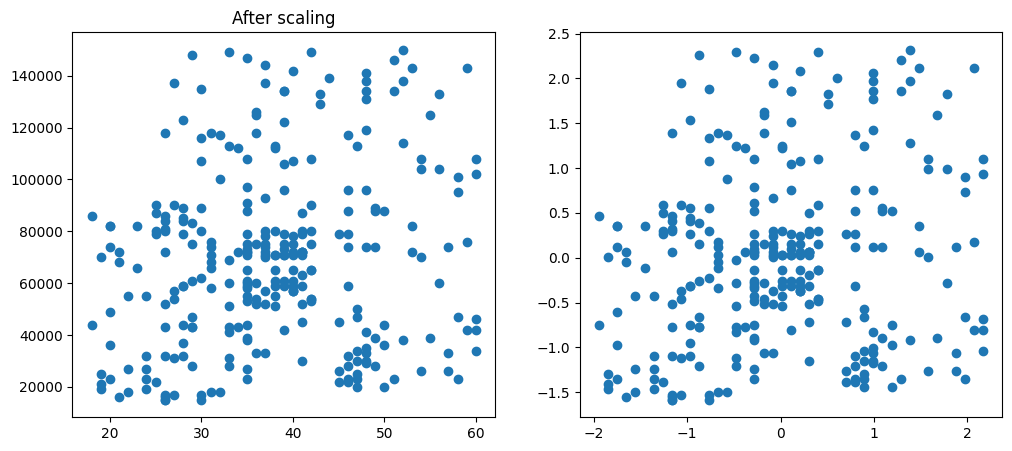

In [34]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
ax1.scatter(x='Age',y='EstimatedSalary',data=X_train,label='Before scaling')
ax1.title.set_text('Before scaling')
ax2.scatter(x='Age',y='EstimatedSalary',data=X_train_sc,label='After scaling')
ax1.title.set_text('After scaling')
plt.show()

#notice values

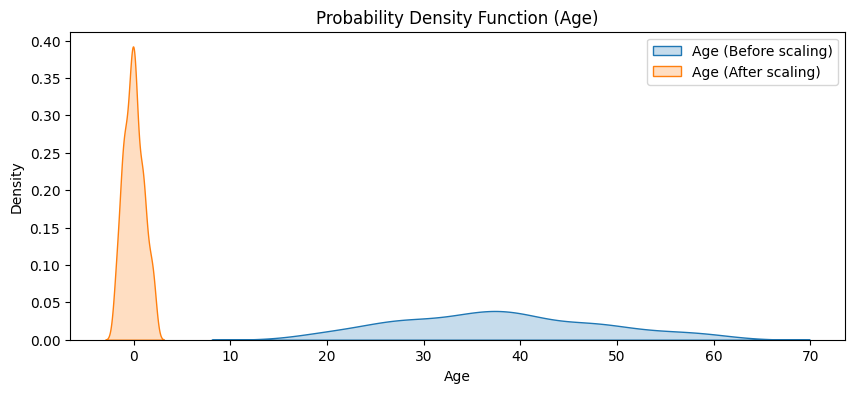

In [37]:
plt.figure(figsize=(10,4))

sns.kdeplot(
    X_train['Age'],
    label='Age (Before scaling)',
    fill=True
)

sns.kdeplot(
    X_train_sc['Age'],
    label='Age (After scaling)',
    fill=True
)

plt.title('Probability Density Function (Age)')
plt.legend()
plt.show()


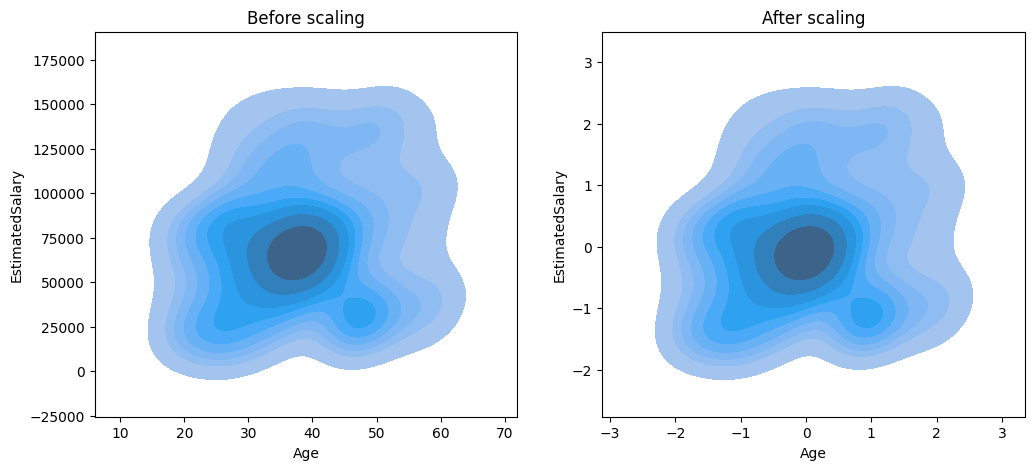

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

sns.kdeplot(
    x=X_train['Age'],
    y=X_train['EstimatedSalary'],
    fill=True,
    ax=ax1
)
ax1.set_title('Before scaling')

sns.kdeplot(
    x=X_train_sc['Age'],
    y=X_train_sc['EstimatedSalary'],
    fill=True,
    ax=ax2
)
ax2.set_title('After scaling')

plt.show()


Why scaling is important


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr_scaled = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)
lr_scaled.fit(X_train_sc, y_train)

y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_sc)

print('Accuracy without scaling:', accuracy_score(y_test, y_pred))
print('Accuracy with scaling:', accuracy_score(y_test, y_pred_scaled))


Accuracy without scaling: 0.875
Accuracy with scaling: 0.8666666666666667


Effect of outliers

In [44]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [47]:
outliers = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased': [0, 1, 1]
})

df = pd.concat([df, outliers], ignore_index=True)
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
401,90,250000,1
402,95,350000,1
403,5,1000,0
404,90,250000,1


Text(0, 0.5, 'Estimated Salary')

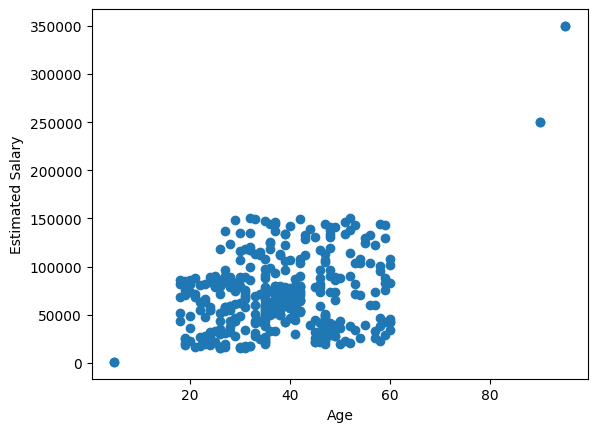

In [48]:
plt.scatter(df['Age'], df['EstimatedSalary'])
plt.xlabel('Age')
plt.ylabel('Estimated Salary')

####OUTLIERS doesnt affect scaling , it behaves same as before.